In [1]:
import os

import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt



In [2]:
independent_feature_cols = ["num_parts", "unique_part_count", "minifig_count", 
                "spare_part_ratio", "h_cat", "h_col", 
                "prop_technic", "prop_printed", "prop_transparent", 
                "rare_part_ratio", "minifig_to_part_ratio", "has_minifigs"]

path = os.path.join("data", "lego_normalized_features.csv")
df = pd.read_csv(path)
windows =  sorted(list(df["window_index"].unique()))

centers = {}
statistics = {}

for w in windows:
    X = df[df["window_index"] == w]
    X = X[independent_feature_cols].values

    km = KMeans(n_clusters = 4, n_init = 10, random_state = 42)
    km_labels = km.fit_predict(X)

    centroids = km.cluster_centers_

    centers[int(w)] = centroids

    min_samples = 2 * X.shape[1]

    db = DBSCAN(eps=5.2014, min_samples=min_samples)
    db_labels = db.fit_predict(X) 

    ari = adjusted_rand_score(km_labels, db_labels)
    nmi = normalized_mutual_info_score(km_labels, db_labels)
    noise_frac = np.mean(db_labels == -1)

    robustness = {"ARI": ari, "NMI": nmi, "Noise Fraction": noise_frac}

    statistics[int(w)] = robustness

print(statistics)

{0: {'ARI': 0.7594598188561044, 'NMI': 0.7316940460504864, 'Noise Fraction': np.float64(0.125)}, 1: {'ARI': 0.29366607435211795, 'NMI': 0.39040725771566853, 'Noise Fraction': np.float64(0.04580152671755725)}, 2: {'ARI': 0.24631872712439426, 'NMI': 0.2764783867368599, 'Noise Fraction': np.float64(0.045454545454545456)}, 3: {'ARI': 0.1408776074093433, 'NMI': 0.18527750798429354, 'Noise Fraction': np.float64(0.03355704697986577)}, 4: {'ARI': 0.9808021792050045, 'NMI': 0.8736469019643097, 'Noise Fraction': np.float64(0.09900990099009901)}, 5: {'ARI': 0.4331562685621016, 'NMI': 0.5172292554052897, 'Noise Fraction': np.float64(0.10948905109489052)}, 6: {'ARI': 0.6157963331156057, 'NMI': 0.4201280048921266, 'Noise Fraction': np.float64(0.14423076923076922)}, 7: {'ARI': 0.18753806904689774, 'NMI': 0.273965285797281, 'Noise Fraction': np.float64(0.0410958904109589)}, 8: {'ARI': 0.3350868409190444, 'NMI': 0.18696554044654978, 'Noise Fraction': np.float64(0.16417910447761194)}, 9: {'ARI': 0.22036

In [20]:
def match_centroids(centroids_a, centroids_b):
    """
    Match rows of centroids_a to rows of centroids_b via Hungarian algorithm
    (minimizes total Euclidean distance). Returns matched pairs of indices
    and the per-pair distances.
    """
    cost = np.linalg.norm(
        centroids_a[:, None, :] - centroids_b[None, :, :], axis=2
    )
    row_ind, col_ind = linear_sum_assignment(cost)
    distances = cost[row_ind, col_ind]
    return row_ind, col_ind, distances


def compute_drift_sequence(centroid_dict):
    """
    centroid_dict: {run_index: ndarray of shape (k, n_features)}
    Returns a DataFrame with per-run drift stats (consecutive-run comparison).
    """
    runs = sorted(centroid_dict.keys())
    records = []

    for prev_run, curr_run in zip(runs[:-1], runs[1:]):
        prev_centroids = centroid_dict[prev_run]
        curr_centroids = centroid_dict[curr_run]

        row_ind, col_ind, distances = match_centroids(prev_centroids, curr_centroids)

        records.append({
            "from_run": prev_run,
            "to_run": curr_run,
            "mean_drift": distances.mean(),
            "max_drift": distances.max(),
            "total_drift": distances.sum(),
            "per_cluster_drift": distances,  # array, one value per matched cluster
        })

    return pd.DataFrame(records)


def compute_drift_vs_baseline(centroid_dict, baseline_run=0):
    """
    Drift of every run's centroids relative to a fixed baseline run,
    rather than consecutive-run drift. Useful for spotting overall
    trend/degradation vs. just local jitter.
    """
    runs = sorted(centroid_dict.keys())
    baseline = centroid_dict[baseline_run]
    records = []

    for run in runs:
        if run == baseline_run:
            continue
        row_ind, col_ind, distances = match_centroids(baseline, centroid_dict[run])
        records.append({
            "run": run,
            "mean_drift": distances.mean(),
            "max_drift": distances.max(),
            "total_drift": distances.sum(),
        })

    return pd.DataFrame(records)


def plot_drift(drift_df, x_col, y_col, title, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(drift_df[x_col], drift_df[y_col], marker="o")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()


In [46]:
def detect_drift_points(drift_values, run_labels, c=1):
    """
    Flags drift points t* where drift(t) > mu_delta + c * sigma_delta.
    """
    drift_values = np.asarray(drift_values, dtype=float)
    mu = drift_values.mean()
    sigma = drift_values.std(ddof=0)
    threshold = mu + c * sigma

    is_flagged = drift_values > threshold

    flagged = pd.DataFrame({
        "run": np.asarray(run_labels)[is_flagged],
        "drift": drift_values[is_flagged],
    }).sort_values("drift", ascending=False).reset_index(drop=True)

    print(f"mu_delta={mu:.3f}, sigma_delta={sigma:.3f}, threshold (mu+{c}*sigma)={threshold:.3f}")
    print(f"Flagged {is_flagged.sum()} / {len(drift_values)} points as drift events (t*)")

    return mu, sigma, threshold, flagged

In [44]:

def plot_drift_with_threshold(drift_df, x_col, y_col, c, title, save_path):
    drift_values = drift_df[y_col].values
    mu = drift_values.mean()
    sigma = drift_values.std(ddof=0)
    threshold = mu + c * sigma

    plt.figure(figsize=(10, 5))
    plt.plot(drift_df[x_col], drift_df[y_col], marker="o", label="drift")
    plt.axhline(mu, color="gray", linestyle=":", label=f"µ={mu:.2f}")
    plt.axhline(threshold, color="red", linestyle="--", label=f"µ+{c}σ={threshold:.2f}")

    flagged = drift_df[drift_df[y_col] > threshold]
    plt.scatter(flagged[x_col], flagged[y_col], color="red", zorder=5, label="t* (drift point)")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()

    return flagged



mu_delta=11.709, sigma_delta=6.519, threshold (mu+1*sigma)=18.228
Flagged 9 / 43 points as drift events (t*)
   run      drift year_window
0   40  23.187328        2023
1   25  22.969314        2008
2   24  22.781085        2007
3   20  22.327929        2003
4   39  21.715745        2022
5   42  21.035786        2025
6   10  20.488829   1992-1993
7   21  20.273138        2004
8    5  19.202690   1982-1984


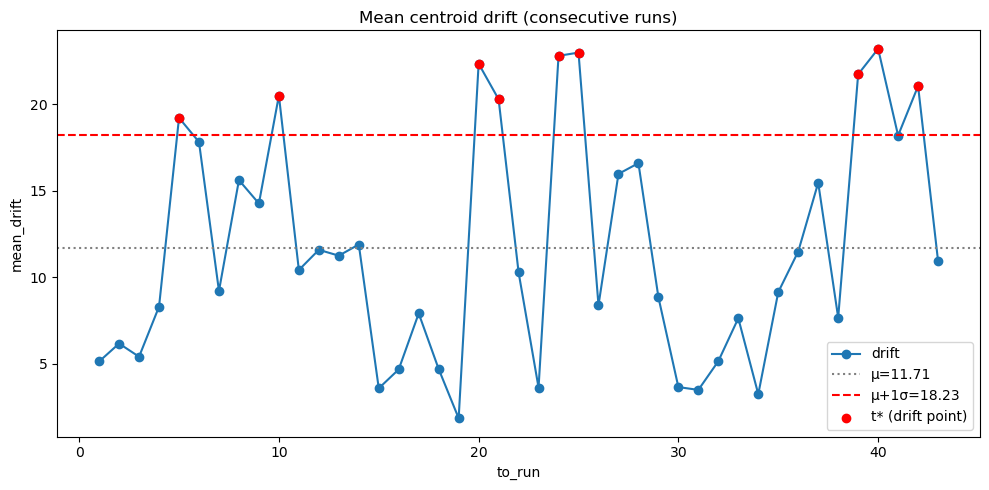

    from_run  to_run  mean_drift  max_drift  total_drift year_window
0          0       1    5.135097  12.952199    20.540387   1967-1973
1          1       2    6.171904  12.958412    24.687614   1974-1976
2          2       3    5.410319   9.853919    21.641277   1977-1979
3          3       4    8.301989  21.208758    33.207957   1980-1981
4          4       5   19.202690  52.971208    76.810759   1982-1984
5          5       6   17.808261  37.005761    71.233043        1985
6          6       7    9.206592  15.758966    36.826367   1986-1987
7          7       8   15.606186  28.349025    62.424743   1988-1989
8          8       9   14.257497  38.043864    57.029987   1990-1991
9          9      10   20.488829  49.974188    81.955317   1992-1993
10        10      11   10.417358  30.962915    41.669433        1994
11        11      12   11.582410  34.167537    46.329641        1995
12        12      13   11.244905  31.155944    44.979620        1996
13        13      14   11.889334  

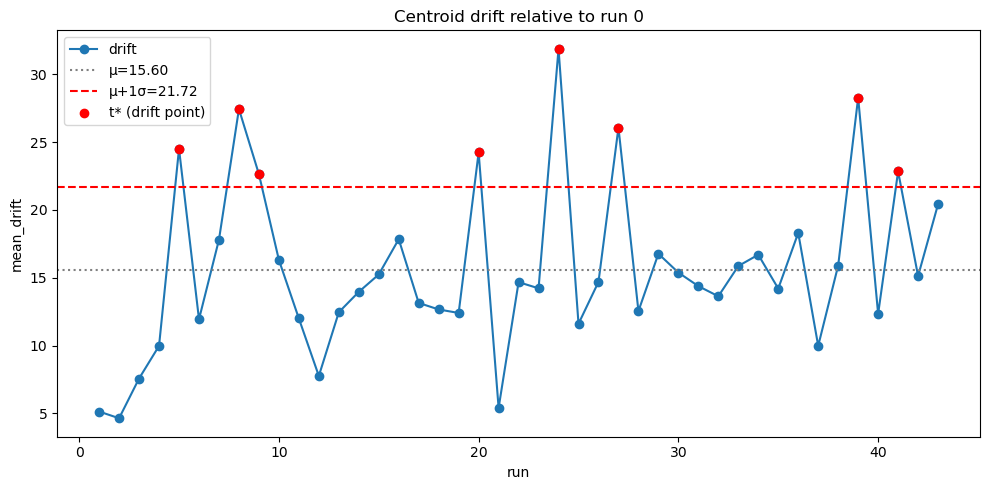

    run  mean_drift  max_drift  total_drift year_window
0     1    5.135097  12.952199    20.540387   1967-1973
1     2    4.639904   9.782121    18.559615   1974-1976
2     3    7.570422   9.908732    30.281686   1977-1979
3     4    9.977007  20.414511    39.908028   1980-1981
4     5   24.511144  78.317286    98.044577   1982-1984
5     6   11.936952  37.329133    47.747807        1985
6     7   17.807425  50.264598    71.229700   1986-1987
7     8   27.444188  69.855326   109.776751   1988-1989
8     9   22.640010  79.915892    90.560040   1990-1991
9    10   16.317297  40.632298    65.269188   1992-1993
10   11   11.998250  36.185113    47.992999        1994
11   12    7.757941  11.129778    31.031763        1995
12   13   12.457750  35.745696    49.831001        1996
13   14   13.960808  34.540229    55.843233        1997
14   15   15.242437  40.830283    60.969747        1998
15   16   17.843288  50.032569    71.373152        1999
16   17   13.145023  32.151852    52.580090     

In [47]:
output_dir = "outputs"

run_to_year = df.set_index("window_index")["year_window"].to_dict()
    

    # --- consecutive-run drift ---
consecutive_drift = compute_drift_sequence(centers)
consecutive_drift["year_window"] = consecutive_drift["to_run"].map(run_to_year)

_, _, _, flagged_consecutive = detect_drift_points(
        consecutive_drift["mean_drift"], consecutive_drift["to_run"], c=1
    )
flagged_consecutive["year_window"] = flagged_consecutive["run"].map(run_to_year)

print(flagged_consecutive)

    # --- baseline-relative drift ---
baseline_drift = compute_drift_vs_baseline(centers, baseline_run=0)
baseline_drift["year_window"] = baseline_drift["run"].map(run_to_year)

    # --- plots ---
consecutive_graph = os.path.join(output_dir, "centroid_drift_consecutive.png")
baseline_graph = os.path.join(output_dir, f"centroid_drift_vs_baseline_{0}.png")

plot_drift_with_threshold(
        consecutive_drift, "to_run", "mean_drift", 1,
        "Mean centroid drift (consecutive runs)",
        consecutive_graph
    )

print(consecutive_drift[["from_run", "to_run", "mean_drift", "max_drift", "total_drift","year_window"]])

plot_drift_with_threshold(
        baseline_drift, "run", "mean_drift", 1,
        f"Centroid drift relative to run {0}",
        baseline_graph
    )

print(baseline_drift)